# Flat Price Classification

### Introduction



The goal of this project is to build an intelligent system that can automatically **classify apartment listings into price tiers** — **Low, Medium, or High** — based on their physical and locational characteristics. Accurate price-tiering matters for **buyers** (budgeting), **sellers/agents** (fair listing and marketing), and **planners** (affordability insights).

Our project applies several machine learning approaches to solve this multi-class problem. We use **supervised learning** methods such as **K-Nearest Neighbors (KNN)**, **Logistic Regression**, and a **Neural Network**, and we also explore **unsupervised learning** via **K-Means clustering** to understand the natural structure of the data. (We additionally compare against **Decision Trees** and **Naive Bayes** as baselines.)

The motivation comes from real housing data challenges: price depends on a **combination** of factors like **size** (`Size_sqft`), **bed/bath count** (`Num_Bedrooms`, `Num_Bathrooms`), **distance to the city center** (`Distance_to_CityCenter_km`), and **building age** (`Building_Age_Years`). Hand-crafted rules are often inconsistent, while ML models can learn subtle patterns and interactions that humans may miss.

Throughout the project we practice key data science steps: **feature engineering** (e.g., `rooms_total`, `size_per_room`, log/binned features), **rare/missing category handling**, **target & frequency encoding** for categorical variables, **scaling/normalization**, **robust filtering** (IsolationForest + consensus checks), **model training**, and **evaluation/visualization**. We evaluate models using **Accuracy**, **Balanced Accuracy**, **Precision/Recall/F1 (macro)**, along with **Confusion Matrices** and **ROC curves** to understand performance across the three price classes.

**Target:** `Price_Category` → mapped to numeric `class` (**Low=0, Medium=1, High=2**).  
**Dataset path:** `/content/flat_price_dataset.csv`


## Data description / EDA

Step 1: Import libraries & setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_score, recall_score, roc_curve, auc, balanced_accuracy_score)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer, PolynomialFeatures, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.dummy import DummyClassifier

try:
    from scikeras.wrappers import KerasClassifier
    from tensorflow import keras
    from tensorflow.keras import layers, callbacks
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow", "scikeras"])
    from scikeras.wrappers import KerasClassifier
    from tensorflow import keras
    from tensorflow.keras import layers, callbacks

sns.set_theme(context="notebook", style="whitegrid")
np.random.seed(42)


Step 2: Load dataset & map target

In [ ]:
df = pd.read_csv("/content/flat_price_dataset.csv")

class_map = {"Low": 0, "Medium": 1, "High": 2}
if "Price_Category" not in df.columns:
    raise ValueError("Expected 'Price_Category' in the dataset.")
df["class"] = df["Price_Category"].map(class_map).astype(int)


Step 3: Structure & types

In [ ]:
print("Rows, Cols:", df.shape)
df.info()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object","category"]).columns.tolist()
print("\nNumeric:", numeric_cols)
print("Categorical:", categorical_cols)


Rows, Cols: (1200, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Location                   1060 non-null   object 
 1   Size_sqft                  1094 non-null   float64
 2   Num_Bedrooms               1064 non-null   float64
 3   Num_Bathrooms              1057 non-null   float64
 4   Has_Balcony                1079 non-null   object 
 5   Floor_Number               1068 non-null   float64
 6   Building_Age_Years         1073 non-null   float64
 7   Parking_Available          1099 non-null   object 
 8   Nearby_Schools             1076 non-null   object 
 9   Distance_to_CityCenter_km  1097 non-null   float64
 10  Security_Level             1074 non-null   object 
 11  Price_Category             1200 non-null   object 
 12  class                      1200 non-null   int64  
dtypes: float64(6), int64(1), 

Step 4: Class balance

class
0    402
1    413
2    385
Name: count, dtype: int64


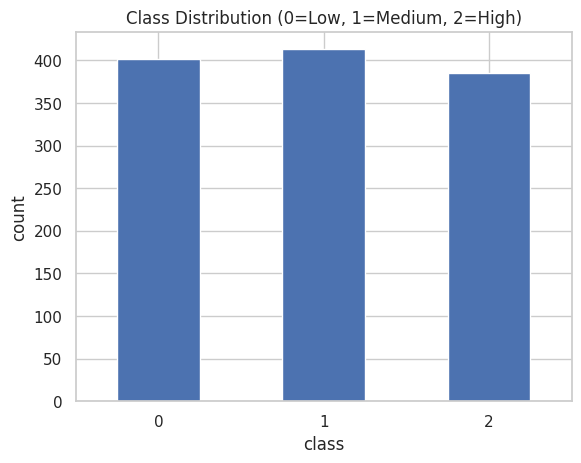

In [ ]:
cls_counts = df["class"].value_counts().sort_index()
print(cls_counts)

ax = cls_counts.plot(kind="bar", rot=0)
ax.set_title("Class Distribution (0=Low, 1=Medium, 2=High)")
ax.set_xlabel("class"); ax.set_ylabel("count")
plt.show()


Step 5: Missing values

,missing_count,missing_%
Num_Bathrooms,143,11.92
Location,140,11.67
Num_Bedrooms,136,11.33
Floor_Number,132,11.00
Building_Age_Years,127,10.58
Security_Level,126,10.50
Nearby_Schools,124,10.33
Has_Balcony,121,10.08
Size_sqft,106,8.83
Distance_to_CityCenter_km,103,8.58


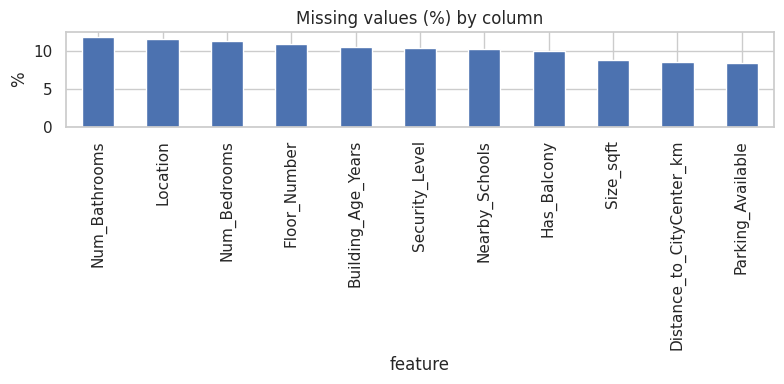

In [ ]:
na_count = df.isna().sum().sort_values(ascending=False)
na_pct   = (na_count / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({"missing_count": na_count, "missing_%": na_pct})
try:
    from IPython.display import display; display(missing_tbl)
except:
    print(missing_tbl.head(20))

na_pct[na_pct>0].plot(kind="bar", figsize=(8,4))
plt.title("Missing values (%) by column"); plt.ylabel("%"); plt.xlabel("feature")
plt.tight_layout(); plt.show()


Step 6: Correlations

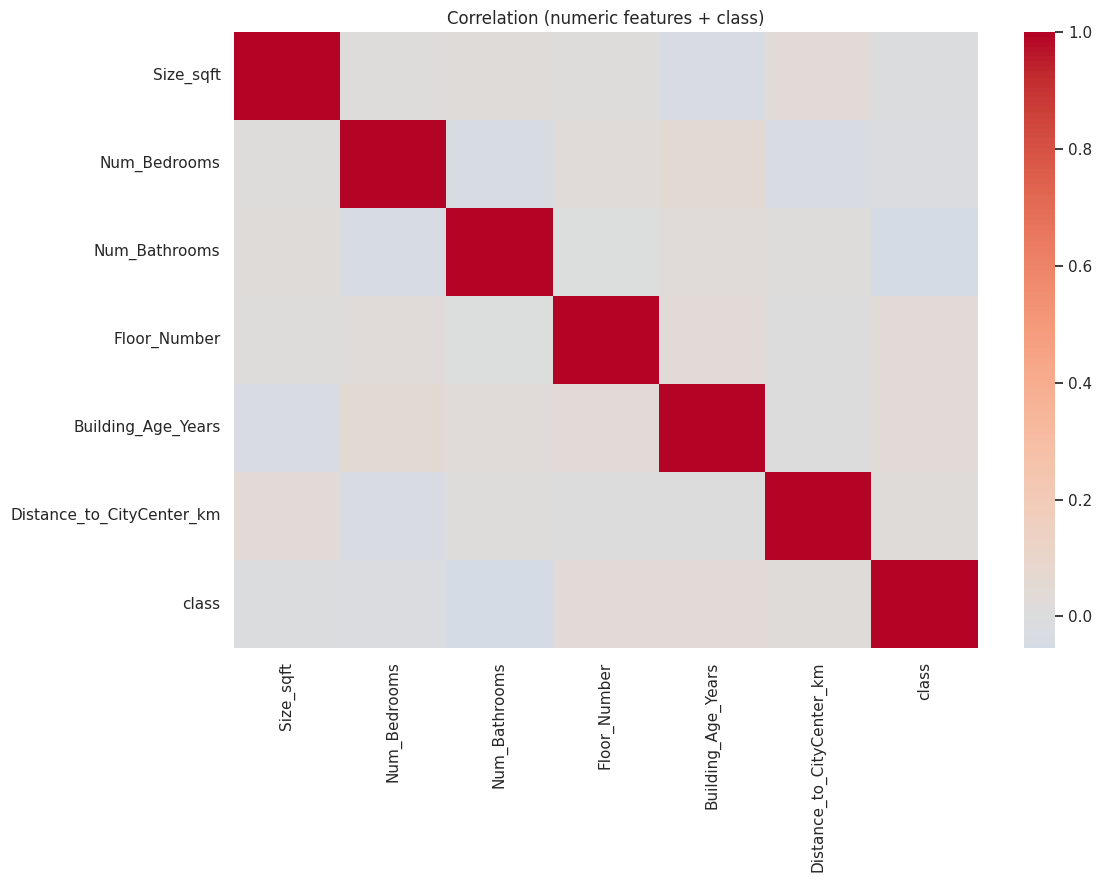


Corr with target:
 Floor_Number                 0.037144
Building_Age_Years           0.033974
Distance_to_CityCenter_km    0.023458
Size_sqft                   -0.012578
Num_Bedrooms                -0.016654
Num_Bathrooms               -0.054774
Name: class, dtype: float64


In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation (numeric features + class)")
plt.show()

if "class" in corr.columns:
    print("\nCorr with target:\n", corr["class"].drop("class").sort_values(ascending=False))


Step 7: Distributions by class

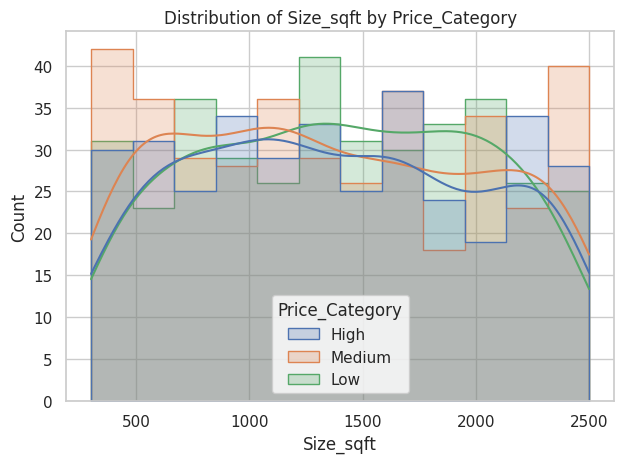

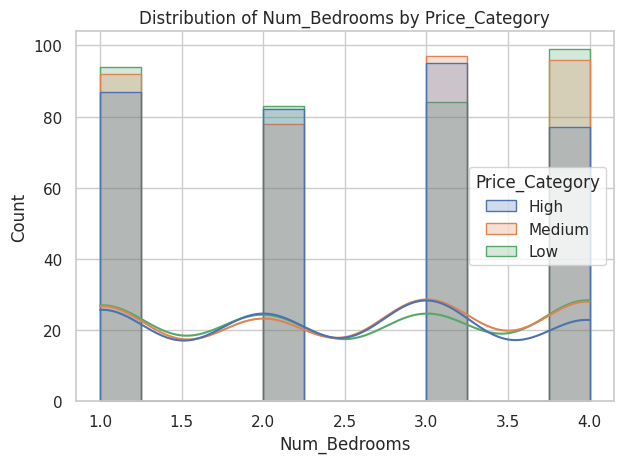

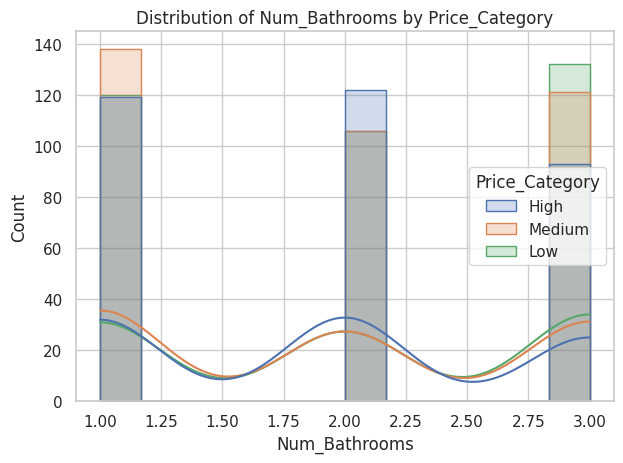

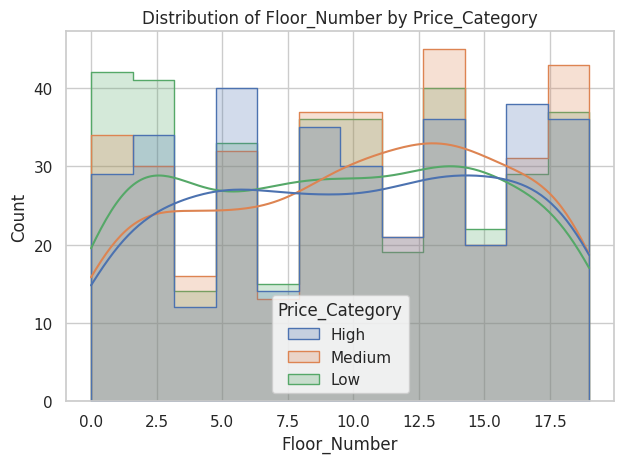

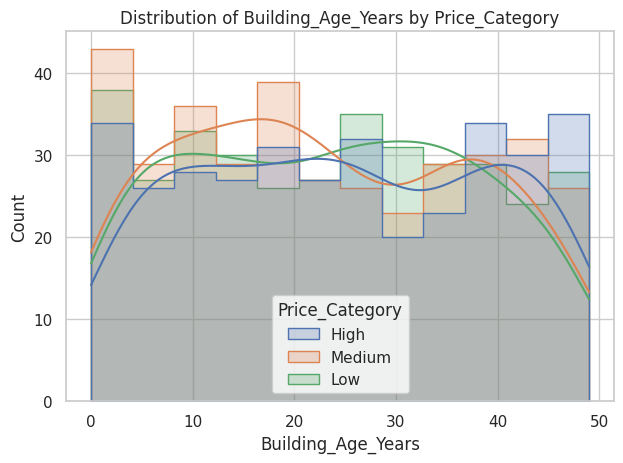

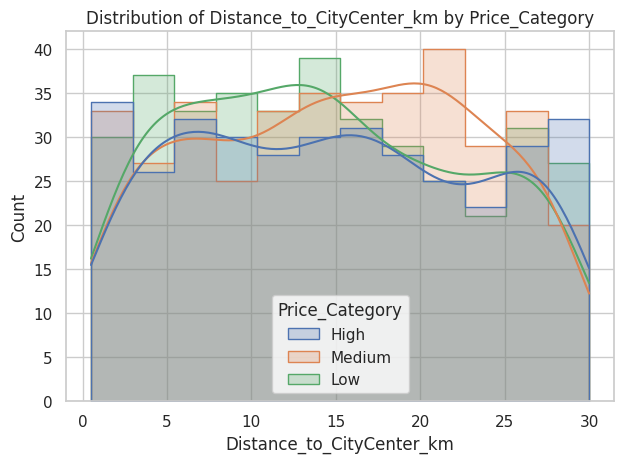

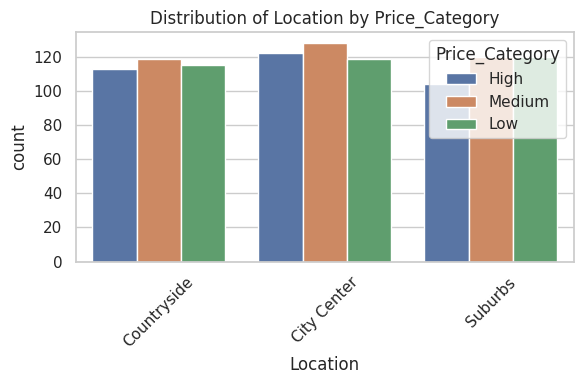

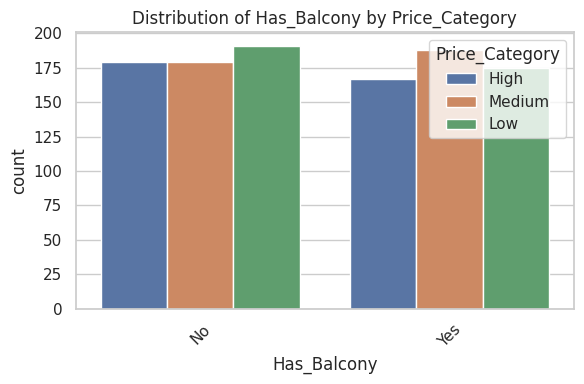

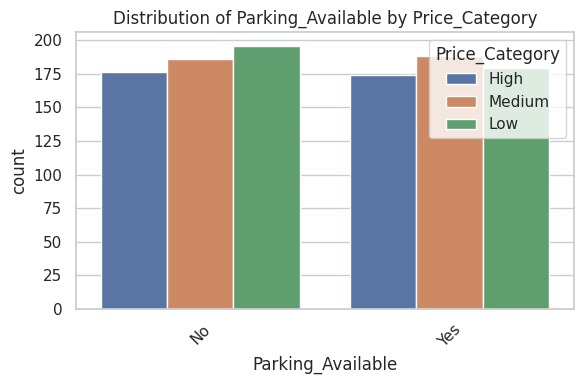

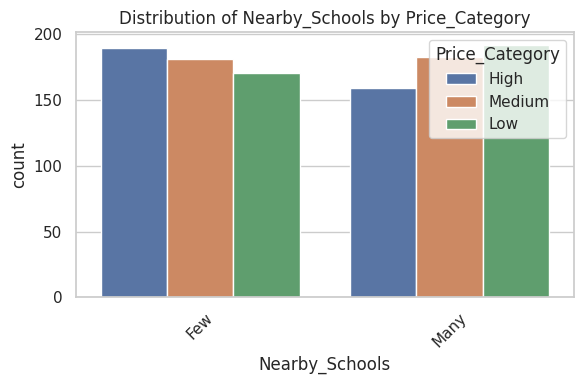

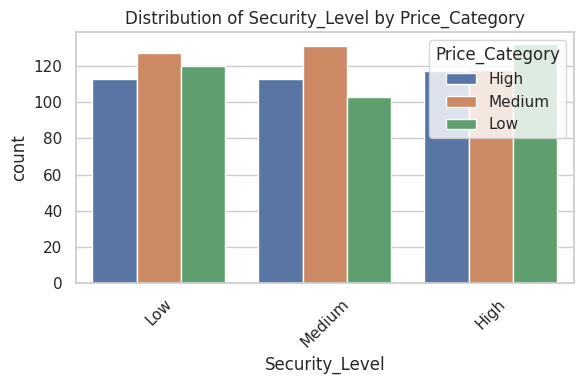

In [ ]:
for col in df.select_dtypes(include=[np.number]).columns:
    if col == "class":
        continue
    sns.histplot(data=df, x=col, hue="Price_Category", kde=True, element="step")
    plt.title(f"Distribution of {col} by Price_Category")
    plt.tight_layout(); plt.show()

for col in df.select_dtypes(include=["object", "category"]).columns:
    if col == "Price_Category":
        continue
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue="Price_Category")
    plt.title(f"Distribution of {col} by Price_Category")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Data splitting

Step 8: Train/test split

In [ ]:
X_raw = df.drop(columns=["class", "Price_Category"], errors="ignore").copy()
y     = df["class"].astype(int).copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train_raw.shape, " Test:", X_test_raw.shape)
print("Train ratio:\n", y_train.value_counts(normalize=True).sort_index())
print("Test  ratio:\n", y_test.value_counts(normalize=True).sort_index())

dum = DummyClassifier(strategy="stratified", random_state=0)
dum.fit(X_train_raw, y_train)
print("Dummy accuracy:", f"{accuracy_score(y_test, dum.predict(X_test_raw))*100:.2f}%")


Train: (840, 11)  Test: (360, 11)
Train ratio:
 class
0    0.334524
1    0.344048
2    0.321429
Name: proportion, dtype: float64
Test  ratio:
 class
0    0.336111
1    0.344444
2    0.319444
Name: proportion, dtype: float64
Dummy accuracy: 36.39%


# Data preprocessing

Step 9: Feature engineering

In [ ]:
def add_features(df_):
    df = df_.copy()
    if {"Num_Bedrooms","Num_Bathrooms"}.issubset(df.columns):
        df["rooms_total"] = df["Num_Bedrooms"].fillna(0) + df["Num_Bathrooms"].fillna(0)
        df["size_per_room"] = df["Size_sqft"] / df["rooms_total"].replace(0, np.nan)
    if "Size_sqft" in df.columns:
        df["log_size"] = np.log1p(np.maximum(df["Size_sqft"], 0))
    if "Distance_to_CityCenter_km" in df.columns:
        df["log_dist"] = np.log1p(np.maximum(df["Distance_to_CityCenter_km"], 0))
        df["dist_bin"] = pd.cut(df["Distance_to_CityCenter_km"], bins=[-1,2,5,10,50], labels=False)
    if "Building_Age_Years" in df.columns:
        df["age_bin"] = pd.cut(df["Building_Age_Years"], bins=[-1,5,10,20,200], labels=False)
    return df

X_train_fe = add_features(X_train_raw)
X_test_fe  = add_features(X_test_raw)

for c in X_train_fe.select_dtypes(include=[np.number]).columns:
    if any(k in c.lower() for k in ["size","room","dist","age","width","height","floor","bath","bed"]):
        X_train_fe.loc[X_train_fe[c] < 0, c] = np.nan
        X_test_fe.loc[X_test_fe[c] < 0, c] = np.nan


Step 10: De-dup & rare/missing categories

In [ ]:
Xy_tr = pd.concat([X_train_fe, y_train.rename("class")], axis=1).drop_duplicates()
X_train_clean = Xy_tr.drop(columns=["class"]).copy()
y_train_clean = Xy_tr["class"].copy()

cat_cols_all = X_train_clean.select_dtypes(include=["object","category"]).columns.tolist()
RARE_MIN_FREQ = 5

def map_rare(train_s, test_s, min_count=RARE_MIN_FREQ):
    counts = train_s.value_counts()
    rare = counts[counts < min_count].index
    tr = train_s.fillna("__MISSING__").where(~train_s.isin(rare), "__RARE__")
    te = test_s.fillna("__MISSING__").where(~test_s.isin(rare), "__RARE__")
    return tr, te

if cat_cols_all:
    X_train_cat = X_train_clean[cat_cols_all].copy()
    X_test_cat  = X_test_fe[cat_cols_all].copy()
    for c in cat_cols_all:
        X_train_cat[c], X_test_cat[c] = map_rare(X_train_clean[c], X_test_fe[c], RARE_MIN_FREQ)
else:
    X_train_cat = pd.DataFrame(index=X_train_clean.index)
    X_test_cat  = pd.DataFrame(index=X_test_fe.index)

num_cols_base = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
X_train_num = X_train_clean[num_cols_base].copy()
X_test_num  = X_test_fe[num_cols_base].copy()


Step 11: Target & frequency encoding

In [ ]:
def _smoothed_probs(counts_df, prior_vec, alpha=30.0):
    counts_df = counts_df.reindex(columns=range(len(prior_vec)), fill_value=0)
    totals = counts_df.sum(axis=1)
    return (counts_df.add(alpha*prior_vec, axis=1)).div((totals + alpha), axis=0)

def kfold_target_encode_multiclass(X_tr, y_tr, X_te, cols, n_splits=5, alpha=30.0, random_state=42):
    n_classes = len(np.unique(y_tr))
    priors = y_tr.value_counts(normalize=True).reindex(range(n_classes), fill_value=0).values
    Xtr_out, Xte_out = X_tr.copy(), X_te.copy()
    oof = {c: np.zeros((X_tr.shape[0], n_classes), float) for c in cols}
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for tr_idx, val_idx in kf.split(X_tr):
        Xt, Xv = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
        yt = y_tr.iloc[tr_idx]
        for col in cols:
            sm = _smoothed_probs(pd.crosstab(Xt[col], yt), priors, alpha)
            m  = sm.reindex(Xv[col]).values

            bad = (np.isnan(m).any(axis=1)) | (~(m.any(axis=1)))
            if bad.any(): m[bad] = priors
            oof[col][val_idx, :] = m
    for col in cols:
        for k in range(n_classes):
            Xtr_out[f"{col}_te_c{k}"] = oof[col][:, k]
    for col in cols:
        sm_full = _smoothed_probs(pd.crosstab(X_tr[col], y_tr), priors, alpha)
        mte = sm_full.reindex(X_te[col]).values
        bad = (np.isnan(mte).any(axis=1)) | (~(mte.any(axis=1)))
        if bad.any(): mte[bad] = priors
        for k in range(n_classes):
            Xte_out[f"{col}_te_c{k}"] = mte[:, k]
    Xtr_out = Xtr_out.drop(columns=cols)
    Xte_out = Xte_out.drop(columns=cols)
    return Xtr_out, Xte_out

if len(cat_cols_all):
    X_train_te, X_test_te = kfold_target_encode_multiclass(
        X_train_cat, y_train_clean, X_test_cat, cols=cat_cols_all, n_splits=5, alpha=30.0, random_state=42
    )
    # frequency encoding
    freq_tr, freq_te = {}, {}
    for c in cat_cols_all:
        f = X_train_cat[c].value_counts(normalize=True)
        freq_tr[f"{c}_freq"] = X_train_cat[c].map(f).fillna(0.0).values
        freq_te[f"{c}_freq"] = X_test_cat[c].map(f).fillna(0.0).values
    X_train_freq = pd.DataFrame(freq_tr, index=X_train_cat.index)
    X_test_freq  = pd.DataFrame(freq_te, index=X_test_cat.index)
else:
    X_train_te   = pd.DataFrame(index=X_train_clean.index)
    X_test_te    = pd.DataFrame(index=X_test_fe.index)
    X_train_freq = pd.DataFrame(index=X_train_clean.index)
    X_test_freq  = pd.DataFrame(index=X_test_fe.index)

Step 12: Combine feature blocks

In [ ]:
X_train_base = pd.concat([X_train_num.reset_index(drop=True),
                          X_train_te.reset_index(drop=True),
                          X_train_freq.reset_index(drop=True)], axis=1)
X_test_base  = pd.concat([X_test_num.reset_index(drop=True),
                          X_test_te.reset_index(drop=True),
                          X_test_freq.reset_index(drop=True)], axis=1)
print("Base shapes:", X_train_base.shape, X_test_base.shape)


Base shapes: (840, 32) (360, 32)


Step 13: Cluster standardized train features into 3 groups and visualize with PCA(2). The crosstab shows how clusters align with true classes (Low/Medium/High).

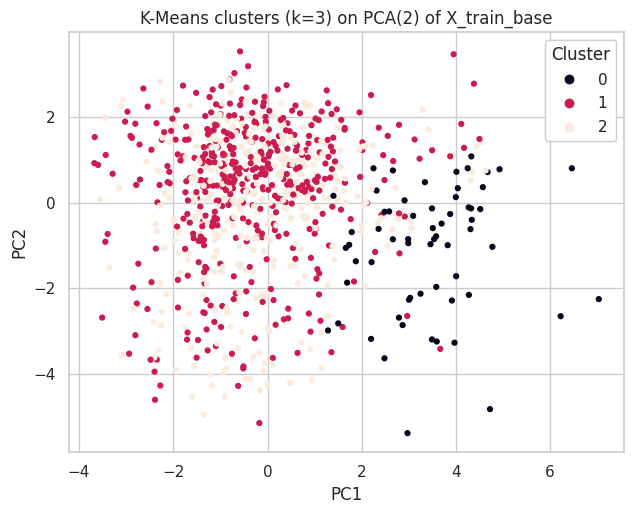

cluster,0,1,2
true_class,,,
0,21,149,111
1,21,153,115
2,20,118,132


In [ ]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


Xtr = X_train_base.values if hasattr(X_train_base, "values") else np.asarray(X_train_base)
imp = SimpleImputer(strategy="median")
sc  = StandardScaler()
Xtr_std = sc.fit_transform(imp.fit_transform(Xtr))

#  K-Means clustering (k=3 for the 3 price tiers)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(Xtr_std)

#  PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(Xtr_std)

#  Scatter plot
fig, ax = plt.subplots(figsize=(6.5,5.3))
scatter = ax.scatter(X2[:, 0], X2[:, 1], c=clusters, s=12)
ax.set_title("K-Means clusters (k=3) on PCA(2) of X_train_base")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.add_artist(legend1)
plt.tight_layout(); plt.show()

try:
    from IPython.display import display
    y_km = (y_train_clean if "y_train_clean" in globals() else y_train).reset_index(drop=True)
    display(pd.crosstab(y_km, pd.Series(clusters, name="cluster"),
                        rownames=["true_class"], colnames=["cluster"]))
except Exception as e:
    print("Crosstab fallback:", e)
    y_km = (y_train_clean if "y_train_clean" in globals() else y_train).reset_index(drop=True)
    print(pd.crosstab(y_km, pd.Series(clusters, name="cluster"),
                      rownames=["true_class"], colnames=["cluster"]))


Step 14: Clip extremes & finalize column list

In [ ]:
for c in X_train_base.columns:
    if np.issubdtype(X_train_base[c].dtype, np.number):
        q1, q99 = X_train_base[c].quantile(0.01), X_train_base[c].quantile(0.99)
        X_train_base[c] = X_train_base[c].clip(q1, q99)
        if c in X_test_base:
            X_test_base[c]  = X_test_base[c].clip(q1, q99)

enc_cols = X_train_base.columns.tolist()


Step 15: Define preprocessors

In [ ]:
preproc_std = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("qt",  QuantileTransformer(output_distribution="normal", random_state=42)),
        ("sc",  StandardScaler())
    ]), enc_cols)]
)

preproc_tree = ColumnTransformer(
    transformers=[("num", SimpleImputer(strategy="median"), enc_cols)]
)

preproc_nb = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("qt",  QuantileTransformer(output_distribution="normal", random_state=42)),
        ("mm",  MinMaxScaler())
    ]), enc_cols)]
)


Step 16: IsolationForest filtering

In [ ]:
Xtr_std = preproc_std.fit_transform(X_train_base)
iso = IsolationForest(n_estimators=300, contamination=0.08, random_state=42)
is_inlier = iso.fit_predict(Xtr_std) == 1
print("IsolationForest kept:", is_inlier.sum(), "/", len(is_inlier))

X_train_f1 = X_train_base.loc[is_inlier].reset_index(drop=True)
y_train_f1 = y_train.loc[is_inlier].reset_index(drop=True)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (840). n_quantiles is set to n_samples.
  warnings.warn(


IsolationForest kept: 772 / 840


Step 17: Consensus & confidence filter

In [ ]:
prep_f1 = preproc_std.fit(X_train_f1, y_train_f1)
Xf1_std = prep_f1.transform(X_train_f1)

knn = KNeighborsClassifier(n_neighbors=11, weights='distance').fit(Xf1_std, y_train_f1)
nbrs = knn.kneighbors(Xf1_std, n_neighbors=11, return_distance=False)
agree = np.array([(y_train_f1.iloc[idxs] == y_train_f1.iloc[i]).mean() for i, idxs in enumerate(nbrs)])

lr = LogisticRegression(max_iter=6000, multi_class="multinomial", solver="lbfgs", C=3.0).fit(Xf1_std, y_train_f1)
proba = lr.predict_proba(Xf1_std); conf_true = proba[np.arange(len(y_train_f1)), y_train_f1.values]

keep_mask = np.ones(len(y_train_f1), dtype=bool)
for cls in np.unique(y_train_f1):
    cls_idx = np.where(y_train_f1.values == cls)[0]
    k_agree = np.quantile(agree[cls_idx], 0.10)
    k_conf  = np.quantile(conf_true[cls_idx], 0.10)
    drop = (agree < k_agree) | (conf_true < k_conf)
    max_drop = int(0.20 * len(cls_idx))
    to_drop_idx = cls_idx[np.where(drop[cls_idx])[0]][:max_drop]
    keep_mask[to_drop_idx] = False

X_train_f2 = X_train_f1.loc[keep_mask].reset_index(drop=True)
y_train_f2 = y_train_f1.loc[keep_mask].reset_index(drop=True)
print("After filters:", X_train_f2.shape, y_train_f2.shape)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (772). n_quantiles is set to n_samples.
  warnings.warn(


After filters: (677, 32) (677,)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Step 18: Refit preprocessors & model heads

In [ ]:
enc_cols_f = X_train_f2.columns.tolist()

preproc_std_f = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("qt",  QuantileTransformer(output_distribution="normal", random_state=42)),
        ("sc",  StandardScaler())
    ]), enc_cols_f)]
)
preproc_tree_f = ColumnTransformer([("num", SimpleImputer(strategy="median"), enc_cols_f)])
preproc_nb_f   = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("qt",  QuantileTransformer(output_distribution="normal", random_state=42)),
        ("mm",  MinMaxScaler())
    ]), enc_cols_f)]
)

pca_dims = min(30, max(12, int(0.25 * X_train_f2.shape[1])))
knn_head = Pipeline([("prep", preproc_std_f), ("pca", PCA(n_components=pca_dims, random_state=42))])

var_series = X_train_f2.var().sort_values(ascending=False)
poly_cols = var_series.index[:min(12, len(var_series))].tolist()
preproc_lr_poly = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("qt",  QuantileTransformer(output_distribution="normal", random_state=42)),
        ("sc",  StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False))
    ]), poly_cols)]
)


# Models

Step 19: Model — KNN

In [ ]:
model_knn = Pipeline([
    ("prep_pca", knn_head),
    ("clf", KNeighborsClassifier(n_neighbors=9, weights='distance', p=2))
])


Step 20: Model — Decision Tree

In [ ]:
model_tree = Pipeline([
    ("prep", preproc_tree_f),
    ("clf", DecisionTreeClassifier(max_depth=14, min_samples_leaf=5, random_state=42))
])


Step 21: Model — Logistic Regression

In [ ]:
model_lr = Pipeline([
    ("prep_poly", preproc_lr_poly),
    ("clf", LogisticRegression(max_iter=8000, multi_class="multinomial", solver="lbfgs", C=5.0))
])


Step 22: Model — Naive Bayes

In [ ]:
model_nb = Pipeline([
    ("prep", preproc_std_f),
    ("clf", GaussianNB())
])


Step 23: Model — Neural Network (Keras)

In [ ]:


from tensorflow import keras
from tensorflow.keras import layers, callbacks

def build_tf_model(n_features, n_classes=3):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)


# Training + accuracy check

Step 24: Train & evaluate (metrics table + reports)

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, balanced_accuracy_score
)


models = {
    "KNN": model_knn,
    "DecisionTree": model_tree,
    "LogReg": model_lr,
    "NaiveBayes": model_nb,
}

LABELS = [0, 1, 2]
TARGET_NAMES = ["Low", "Medium", "High"]

acc_rows, preds = [], {}

#  Train/predict sklearn pipelines
for name, pipe in models.items():
    print(f"Training: {name}")
    pipe.fit(X_train_f2, y_train_f2)
    y_pred = pipe.predict(X_test_base)
    preds[name] = y_pred

    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    p    = precision_score(y_test, y_pred, labels=LABELS, average="macro", zero_division=0)
    r    = recall_score(y_test,  y_pred, labels=LABELS, average="macro", zero_division=0)
    f1   = f1_score(y_test,      y_pred, labels=LABELS, average="macro", zero_division=0)
    acc_rows.append([name, acc, bacc, p, r, f1])


prep_tf = preproc_std_f.fit(X_train_f2, y_train_f2)
Xtr_tf = prep_tf.transform(X_train_f2)
Xte_tf = prep_tf.transform(X_test_base)


if hasattr(Xtr_tf, "toarray"): Xtr_tf = Xtr_tf.toarray()
if hasattr(Xte_tf, "toarray"): Xte_tf = Xte_tf.toarray()
Xtr_tf = Xtr_tf.astype("float32")
Xte_tf = Xte_tf.astype("float32")

print("Training: Neural Network")
tf_model = build_tf_model(n_features=Xtr_tf.shape[1], n_classes=len(LABELS))
history = tf_model.fit(
    Xtr_tf, y_train_f2.values,
    epochs=120, batch_size=64, verbose=0,
    validation_split=0.12, callbacks=[early_stop]
)

proba_tf = tf_model.predict(Xte_tf, verbose=0)
y_pred_tf = proba_tf.argmax(axis=1)
preds["Neural Network"] = y_pred_tf

acc  = accuracy_score(y_test, y_pred_tf)
bacc = balanced_accuracy_score(y_test, y_pred_tf)
p    = precision_score(y_test, y_pred_tf, labels=LABELS, average="macro", zero_division=0)
r    = recall_score(y_test,  y_pred_tf, labels=LABELS, average="macro", zero_division=0)
f1   = f1_score(y_test,      y_pred_tf, labels=LABELS, average="macro", zero_division=0)
acc_rows.append(["Neural Network", acc, bacc, p, r, f1])

# C) Summary + reports
summary_df = pd.DataFrame(acc_rows, columns=[
    "Model","Accuracy","Balanced_Acc","Precision(macro)","Recall(macro)","F1(macro)"
]).sort_values("Accuracy", ascending=False).reset_index(drop=True)

summary_df["Accuracy_%"] = (summary_df["Accuracy"]*100).round(2)
summary_df["Balanced_Acc_%"] = (summary_df["Balanced_Acc"]*100).round(2)

print(summary_df[["Model","Accuracy_%","Balanced_Acc_%","Precision(macro)","Recall(macro)","F1(macro)"]])

for name in preds:
    print(f"\n{name} — accuracy: {accuracy_score(y_test, preds[name])*100:.2f}%")
    print(classification_report(y_test, preds[name],
                                labels=LABELS, target_names=TARGET_NAMES,
                                zero_division=0, digits=2))


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (677). n_quantiles is set to n_samples.
  warnings.warn(


Training: KNN
Training: DecisionTree
Training: LogReg


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (677). n_quantiles is set to n_samples.
  warnings.warn(


Training: NaiveBayes


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (677). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (677). n_quantiles is set to n_samples.
  warnings.warn(


Training: Neural Network
            Model  Accuracy_%  Balanced_Acc_%  Precision(macro)  \
0             KNN       38.33           38.43          0.379253   
1  Neural Network       35.56           35.50          0.355207   
2    DecisionTree       33.06           32.77          0.322773   
3          LogReg       32.50           32.38          0.322412   
4      NaiveBayes       29.44           29.65          0.306054   

   Recall(macro)  F1(macro)  
0       0.384336   0.371752  
1       0.354971   0.351320  
2       0.327730   0.322693  
3       0.323802   0.321544  
4       0.296473   0.278017  

KNN — accuracy: 38.33%
              precision    recall  f1-score   support

         Low       0.39      0.56      0.46       121
      Medium       0.35      0.23      0.28       124
        High       0.39      0.37      0.38       115

    accuracy                           0.38       360
   macro avg       0.38      0.38      0.37       360
weighted avg       0.38      0.38      0.3

# Visual evaluation

Step 25: Accuracy chart

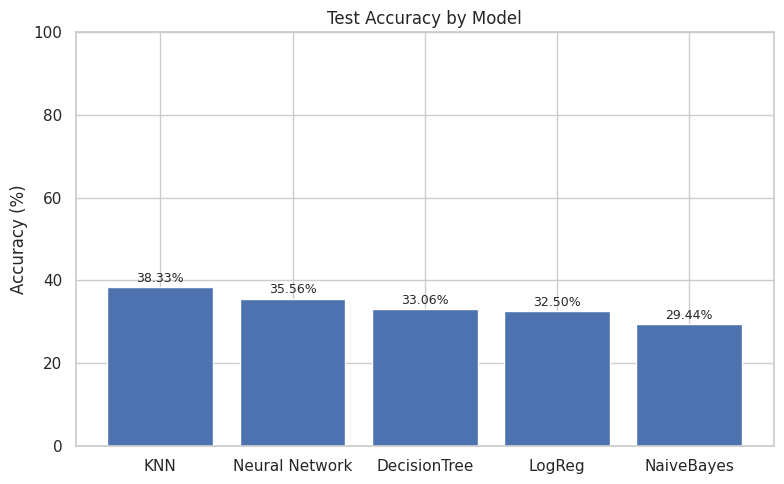

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(summary_df['Model'], summary_df['Accuracy']*100)
ax.set_ylabel('Accuracy (%)'); ax.set_title('Test Accuracy by Model')
for i, v in enumerate(summary_df['Accuracy']*100):
    ax.text(i, v + 0.6, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(100, (summary_df['Accuracy']*100).max()+5))
plt.tight_layout(); plt.show()


Step 26: Precision vs Recall (macro)

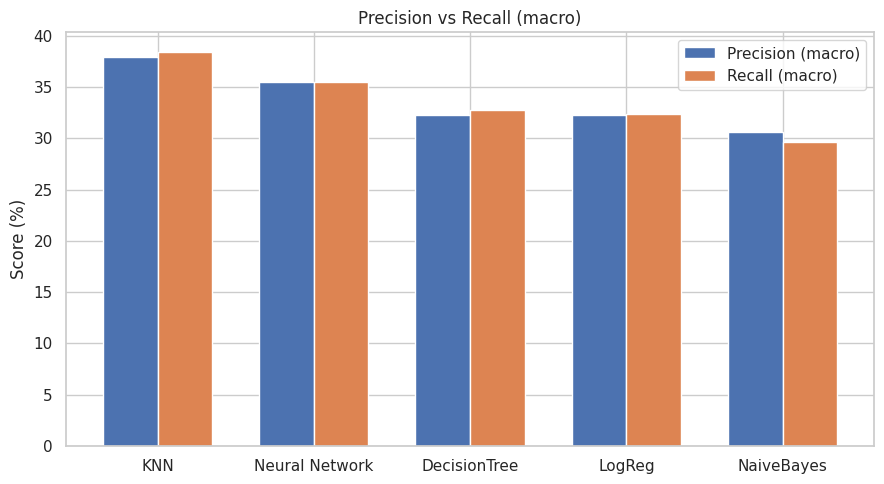

In [ ]:
w = 0.35
x = np.arange(len(summary_df))
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x - w/2, summary_df['Precision(macro)']*100, width=w, label='Precision (macro)')
ax.bar(x + w/2, summary_df['Recall(macro)']*100,    width=w, label='Recall (macro)')
ax.set_xticks(x); ax.set_xticklabels(summary_df['Model'])
ax.set_ylabel('Score (%)'); ax.set_title('Precision vs Recall (macro)')
ax.legend()
plt.tight_layout(); plt.show()


Step 27: Confusion matrices

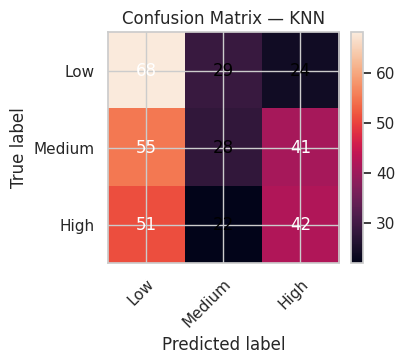

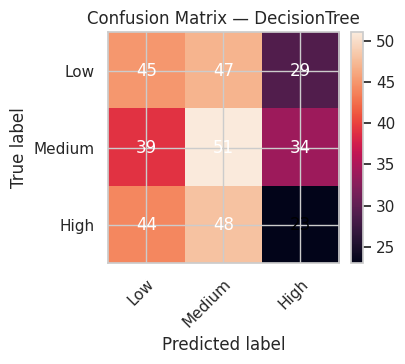

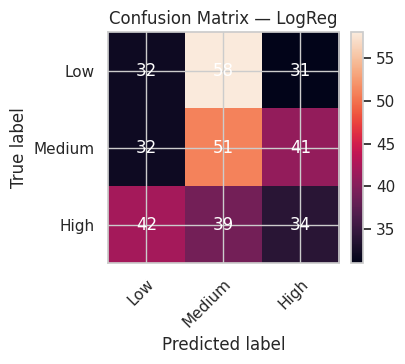

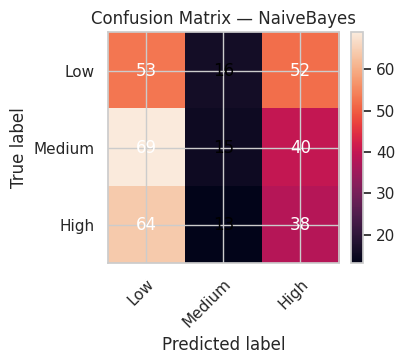

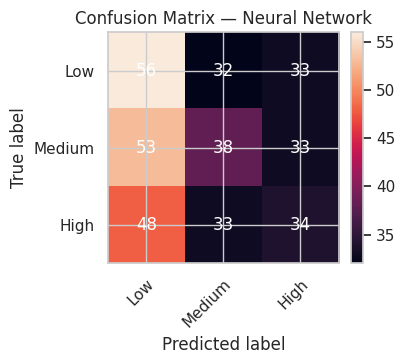

In [ ]:
from sklearn.metrics import confusion_matrix

for name in preds:
    cm = confusion_matrix(y_test, preds[name], labels=LABELS)
    fig, ax = plt.subplots(figsize=(4.5,3.8))
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xticks(np.arange(len(TARGET_NAMES))); ax.set_yticks(np.arange(len(TARGET_NAMES)))
    ax.set_xticklabels(TARGET_NAMES); ax.set_yticklabels(TARGET_NAMES)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')

    ax.set_ylabel('True label'); ax.set_xlabel('Predicted label')
    plt.tight_layout(); plt.show()


Step 28: ROC curves (multiclass)

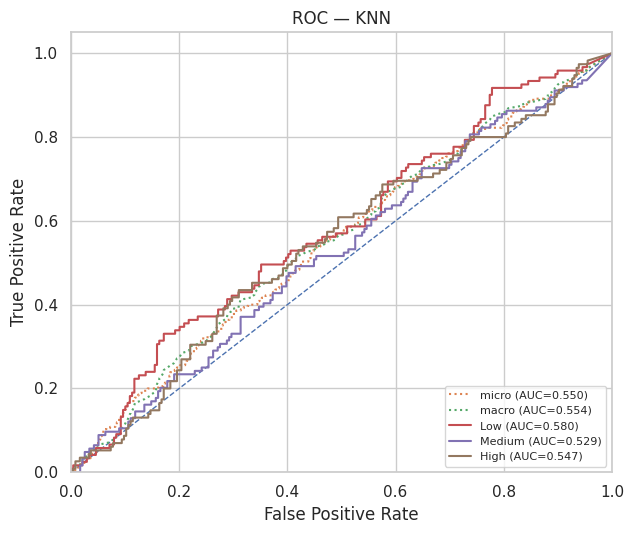

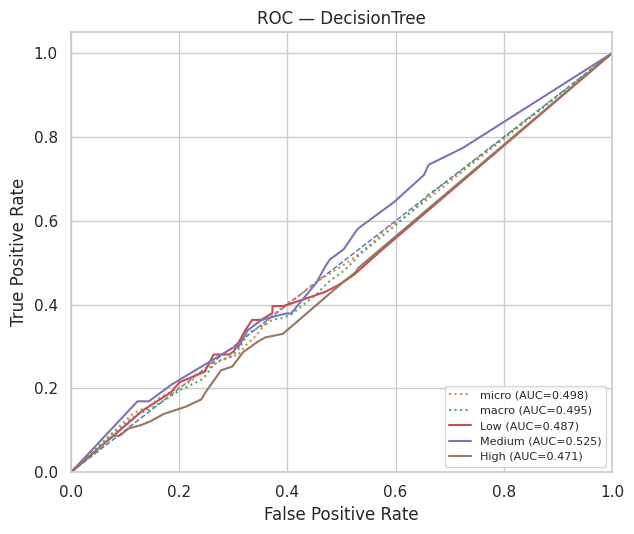

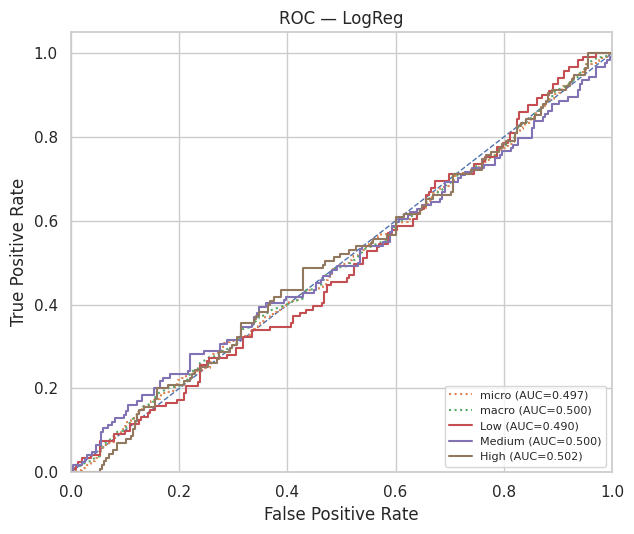

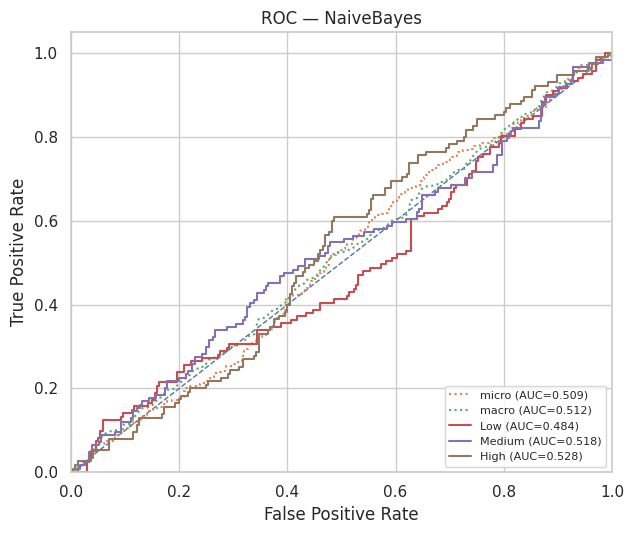

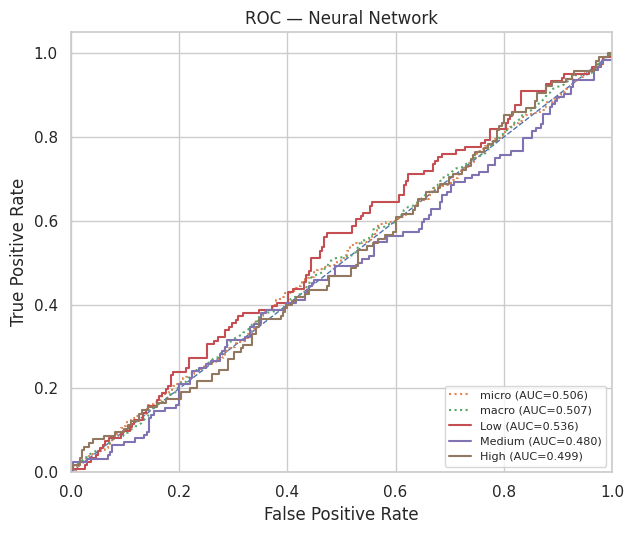

In [ ]:
from sklearn.preprocessing import label_binarize

Y_test_bin = label_binarize(y_test, classes=LABELS)
n_classes = Y_test_bin.shape[1]

def _plot_roc_block(name, proba):
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(Y_test_bin.ravel(), proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes): mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    plt.figure(figsize=(6.5,5.5))
    plt.plot([0,1], [0,1], linestyle='--', linewidth=1)
    plt.plot(fpr["micro"], tpr["micro"], linestyle=':', label=f'micro (AUC={roc_auc["micro"]:.3f})')
    plt.plot(fpr["macro"], tpr["macro"], linestyle=':', label=f'macro (AUC={roc_auc["macro"]:.3f})')
    for i, cls_name in enumerate(TARGET_NAMES):
        plt.plot(fpr[i], tpr[i], label=f'{cls_name} (AUC={roc_auc[i]:.3f})')
    plt.xlim([0,1]); plt.ylim([0,1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC — {name}')
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout(); plt.show()


for name, pipe in models.items():
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(X_test_base)
        _plot_roc_block(name, proba)
    else:
        print(f"Skipping {name}: no predict_proba")

try:
    _plot_roc_block("Neural Network", proba_tf)
except NameError:
    print("Neural Network ROC skipped — run cell-23 first to compute `proba_tf`.")
